# Лабораторная работа №4: Свойства оценок, полученных методом максимального правдоподобия

**Цель работы:** применить метод максимального правдоподобия к двум распределениям,
получить оценки параметров и посмотреть, как меняется устойчивость этих оценок
при росте размера выборки.

Ниже решение сделано в максимально простой форме:
- сначала выводим формулы по шагам;
- затем сразу реализуем именно эти формулы в коде;
- после этого проводим моделирование;
- в конце отдельно проверяем, что все пункты задания действительно выполнены.

**Что будем делать в этой работе:**
1. Для равномерного распределения найдём оценки `a*` и `b*`.
2. Для распределения Лапласа найдём оценку `lambda*`.
3. Для оценок `a*`, `b*` и `lambda*` построим графики зависимости оценки
   среднеквадратического отклонения от размера выборки.

## План ноутбука

1. Подготовка: импорт библиотек и настройка параметров эксперимента.
2. Пункт 1: теория и код для равномерного распределения.
3. Пункт 2: теория и код для распределения Лапласа.
4. Пункт 3: моделирование, оценка СКО и построение графиков.
5. Проверка выполнения задания по пунктам.
6. Краткие выводы.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
SAMPLE_SIZES = [10, 20, 50, 100, 200, 500, 1000]
N_REPEATS = 1000

UNIFORM_TRUE_A = 0.0
UNIFORM_TRUE_B = 1.0

LAPLACE_TRUE_C = 0.0
LAPLACE_TRUE_LAMBDA = 1.0

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [2]:
def print_table(rows, headers):
    widths = [len(str(header)) for header in headers]

    for row in rows:
        for index, value in enumerate(row):
            widths[index] = max(widths[index], len(str(value)))

    fmt = " | ".join("{:" + str(width) + "}" for width in widths)
    sep = "-+-".join("-" * width for width in widths)

    print(fmt.format(*headers))
    print(sep)
    for row in rows:
        print(fmt.format(*row))


def estimate_std(values):
    """
    Эмпирическая оценка среднеквадратического отклонения.

    В работе будем использовать обычное выборочное стандартное отклонение
    по множеству повторных экспериментов.
    """
    values = np.asarray(values, dtype=float)
    return float(np.std(values, ddof=1))

## Подготовка

В этой работе нам достаточно двух библиотек:
- `numpy` для вычислений и генерации выборок;
- `matplotlib` для графиков.

Параметры моделирования выбраны простыми и прозрачными:
- для равномерного распределения используем `U[0, 1]`;
- для распределения Лапласа используем `c = 0`, `lambda = 1`;
- размеры выборки берём от `10` до `1000`;
- для каждого размера выборки повторяем эксперимент `1000` раз.

Один фиксированный `SEED` нужен для воспроизводимости:
если заново запустить ноутбук, будут получаться те же результаты.

## Пункт 1. Оценки `a*` и `b*` для равномерного распределения

Пусть случайная величина имеет плотность

$$
\varphi_r(x, a, b) =
\begin{cases}
\dfrac{1}{b-a}, & x \in [a, b], \\
0, & x \notin [a, b].
\end{cases}
$$

Пусть выборка состоит из значений `x1, x2, ..., xn`.
Тогда функция правдоподобия равна

$$
L(a, b) = \prod_{i=1}^{n} \varphi_r(x_i, a, b).
$$

Для равномерного распределения это можно переписать так:

$$
L(a, b) =
\left(\dfrac{1}{b-a}\right)^n
\cdot
I\{a \le x_1 \le b,\; \dots,\; a \le x_n \le b\},
$$

где `I{...}` это индикатор события.

Что это означает простыми словами:
- если хотя бы одно наблюдение не попало в отрезок `[a, b]`,
  то правдоподобие равно нулю;
- если вся выборка лежит внутри `[a, b]`,
  то правдоподобие равно `(1 / (b - a))^n`.

Значит, чтобы правдоподобие было как можно больше:
- нужно обязательно накрыть весь набор наблюдений отрезком `[a, b]`;
- среди всех таких отрезков нужно выбрать самый короткий,
  потому что чем меньше `b - a`, тем больше `(1 / (b - a))^n`.

Самый короткий отрезок, содержащий всю выборку, это

$$
[\min(x_1, \dots, x_n),\; \max(x_1, \dots, x_n)].
$$

Поэтому оценки максимального правдоподобия имеют вид

$$
a^* = \min(x_1, \dots, x_n), \qquad
b^* = \max(x_1, \dots, x_n).
$$

In [3]:
def uniform_mle(sample):
    sample = np.asarray(sample, dtype=float)
    a_hat = float(np.min(sample))
    b_hat = float(np.max(sample))
    return a_hat, b_hat

В коде реализация буквально повторяет полученную формулу:
- `a*` это минимум выборки;
- `b*` это максимум выборки.

Никаких дополнительных преобразований не нужно, потому что теоретический вывод
уже дал нам окончательный ответ.

In [4]:
uniform_demo_sample = np.array([0.2, 0.7, 0.4, 0.55, 0.31], dtype=float)
uniform_a_hat, uniform_b_hat = uniform_mle(uniform_demo_sample)

print("Демонстрационная выборка для равномерного распределения:")
print(uniform_demo_sample)
print()
print(f"a* = min(sample) = {uniform_a_hat:.4f}")
print(f"b* = max(sample) = {uniform_b_hat:.4f}")

Демонстрационная выборка для равномерного распределения:
[0.2  0.7  0.4  0.55 0.31]

a* = min(sample) = 0.2000
b* = max(sample) = 0.7000


На этом примере хорошо видно, что функция `uniform_mle` делает ровно то,
что требуется по теории:
- берёт самый левый элемент выборки как оценку `a*`;
- берёт самый правый элемент выборки как оценку `b*`.

## Пункт 2. Оценка `lambda*` для распределения Лапласа

Плотность распределения Лапласа задана формулой

$$
\varphi_r(x, c, \lambda) = \dfrac{\lambda}{2} e^{-\lambda |x-c|}.
$$

По условию нам нужна оценка `lambda*`.
В этой работе будем считать, что параметр `c` неизвестен и тоже оценивается.

Для выборки `x1, x2, ..., xn` функция правдоподобия равна

$$
L(c, \lambda)
=
\prod_{i=1}^{n}
\dfrac{\lambda}{2} e^{-\lambda |x_i-c|}.
$$

Перемножим одинаковые множители:

$$
L(c, \lambda)
=
\left(\dfrac{\lambda}{2}\right)^n
e^{-\lambda \sum_{i=1}^{n} |x_i-c|}.
$$

Возьмём логарифм:

$$
\ln L(c, \lambda)
=
n \ln \lambda - n \ln 2 - \lambda \sum_{i=1}^{n} |x_i-c|.
$$

Теперь рассмотрим два шага.

**Шаг 1. Максимизация по `c`.**

В этой формуле `c` входит только в сумму

$$
\sum_{i=1}^{n} |x_i-c|.
$$

Чтобы логарифм правдоподобия был максимальным, эту сумму нужно сделать минимальной.
Из известного свойства медианы следует, что сумма модулей отклонений минимальна
в точке выборочной медианы.

Значит,

$$
c^* = \operatorname{med}(x_1, \dots, x_n).
$$

**Шаг 2. Максимизация по `lambda`.**

Теперь считаем `c` фиксированным и дифференцируем по `lambda`:

$$
\frac{\partial \ln L}{\partial \lambda}
=
\frac{n}{\lambda} - \sum_{i=1}^{n} |x_i-c|.
$$

Приравниваем производную к нулю:

$$
\frac{n}{\lambda} - \sum_{i=1}^{n} |x_i-c| = 0.
$$

Отсюда

$$
\lambda^*(c) = \frac{n}{\sum_{i=1}^{n} |x_i-c|}.
$$

Подставляем `c = c*`, то есть выборочную медиану:

$$
\lambda^* =
\frac{n}{\sum_{i=1}^{n} |x_i-c^*|},
\qquad
c^* = \operatorname{med}(x_1, \dots, x_n).
$$

Именно эту формулу и реализуем в коде.

In [5]:
def laplace_c_mle(sample):
    sample = np.asarray(sample, dtype=float)
    return float(np.median(sample))


def laplace_lambda_mle(sample):
    sample = np.asarray(sample, dtype=float)
    c_hat = laplace_c_mle(sample)
    denominator = float(np.sum(np.abs(sample - c_hat)))

    if denominator <= 0:
        raise ValueError("Сумма |xi - c*| должна быть положительной для оценки lambda*.")

    return float(len(sample) / denominator)

Замечание про чётный размер выборки:
`numpy.median` для чётного числа наблюдений берёт среднее двух центральных значений.
Это не мешает решению, потому что любая точка из медианного интервала минимизирует
сумму `sum(|xi - c|)`, а значит подходит для ММП-логики.

In [6]:
laplace_demo_sample = np.array([-2.0, -0.4, 0.0, 0.3, 1.1], dtype=float)
laplace_c_hat = laplace_c_mle(laplace_demo_sample)
laplace_lambda_hat = laplace_lambda_mle(laplace_demo_sample)
laplace_denominator = float(np.sum(np.abs(laplace_demo_sample - laplace_c_hat)))

print("Демонстрационная выборка для распределения Лапласа:")
print(laplace_demo_sample)
print()
print(f"c* = median(sample) = {laplace_c_hat:.4f}")
print(f"sum(|xi - c*|) = {laplace_denominator:.4f}")
print(f"lambda* = n / sum(|xi - c*|) = {laplace_lambda_hat:.4f}")

Демонстрационная выборка для распределения Лапласа:
[-2.  -0.4  0.   0.3  1.1]

c* = median(sample) = 0.0000
sum(|xi - c*|) = 3.8000
lambda* = n / sum(|xi - c*|) = 1.3158


Здесь тоже код повторяет теорию буквально:
1. находим выборочную медиану `c*`;
2. считаем сумму расстояний до этой медианы;
3. делим `n` на полученную сумму.

## Пункт 3. Моделирование и график зависимости оценки СКО от размера выборки

По условию нужно запрограммировать расчёты по полученным оценкам и построить график
зависимости оценки их среднеквадратического отклонения от размера выборки.

Что будем делать на практике:
1. Выберем несколько размеров выборки `n`.
2. Для каждого `n` много раз сгенерируем новые выборки.
3. Для каждой выборки посчитаем оценки:
   - `a*` и `b*` для равномерного распределения;
   - `lambda*` для распределения Лапласа.
4. Для каждого набора оценок посчитаем эмпирическое стандартное отклонение.

Это и будет оценка того, насколько сильно "колеблется" статистическая оценка
от выборки к выборке.

Если при росте `n` СКО уменьшается, это означает, что оценка становится устойчивее.

In [7]:
def simulate_uniform_std(sample_sizes, repeats, rng):
    results = {"n": [], "std_a_hat": [], "std_b_hat": []}

    for n in sample_sizes:
        a_hats = np.empty(repeats, dtype=float)
        b_hats = np.empty(repeats, dtype=float)

        for repeat_index in range(repeats):
            sample = rng.uniform(UNIFORM_TRUE_A, UNIFORM_TRUE_B, size=n)
            a_hat, b_hat = uniform_mle(sample)
            a_hats[repeat_index] = a_hat
            b_hats[repeat_index] = b_hat

        results["n"].append(n)
        results["std_a_hat"].append(estimate_std(a_hats))
        results["std_b_hat"].append(estimate_std(b_hats))

    return results


def simulate_laplace_std(sample_sizes, repeats, rng):
    results = {"n": [], "std_lambda_hat": []}

    for n in sample_sizes:
        lambda_hats = np.empty(repeats, dtype=float)

        for repeat_index in range(repeats):
            sample = rng.laplace(loc=LAPLACE_TRUE_C, scale=1.0 / LAPLACE_TRUE_LAMBDA, size=n)
            lambda_hats[repeat_index] = laplace_lambda_mle(sample)

        results["n"].append(n)
        results["std_lambda_hat"].append(estimate_std(lambda_hats))

    return results

В этих функциях специально нет ничего сложного:
- один внешний цикл идёт по размерам выборки;
- внутренний цикл много раз повторяет эксперимент;
- потом по массиву полученных оценок считается стандартное отклонение.

То есть логика полностью совпадает с постановкой задачи.

In [8]:
rng_uniform = np.random.default_rng(SEED)
rng_laplace = np.random.default_rng(SEED)

uniform_std_results = simulate_uniform_std(SAMPLE_SIZES, N_REPEATS, rng_uniform)
laplace_std_results = simulate_laplace_std(SAMPLE_SIZES, N_REPEATS, rng_laplace)

rows = []
for index, n in enumerate(SAMPLE_SIZES):
    rows.append(
        (
            n,
            f"{uniform_std_results['std_a_hat'][index]:.6f}",
            f"{uniform_std_results['std_b_hat'][index]:.6f}",
            f"{laplace_std_results['std_lambda_hat'][index]:.6f}",
        )
    )

print_table(
    rows,
    headers=["n", "СКО(a*)", "СКО(b*)", "СКО(lambda*)"],
)

n    | СКО(a*)  | СКО(b*)  | СКО(lambda*)
-----+----------+----------+-------------
  10 | 0.082228 | 0.088111 | 0.437953    
  20 | 0.046646 | 0.048093 | 0.254181    
  50 | 0.019443 | 0.020446 | 0.154427    
 100 | 0.009980 | 0.008782 | 0.102550    
 200 | 0.005009 | 0.004762 | 0.073564    
 500 | 0.001987 | 0.001883 | 0.044908    
1000 | 0.001029 | 0.000930 | 0.030982    


Таблица выше показывает численные результаты моделирования.
Уже по ней обычно видно, что при росте `n` значения СКО уменьшаются.
Теперь построим графики, чтобы зависимость было легче увидеть.

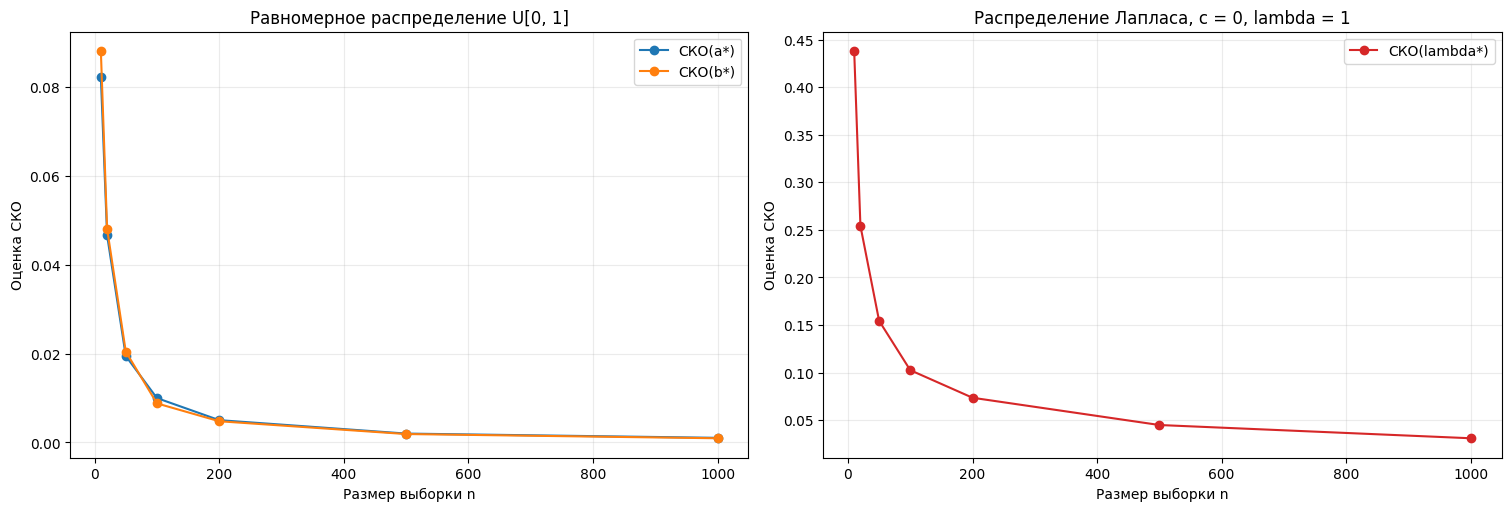

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].plot(
    uniform_std_results["n"],
    uniform_std_results["std_a_hat"],
    marker="o",
    label="СКО(a*)",
)
axes[0].plot(
    uniform_std_results["n"],
    uniform_std_results["std_b_hat"],
    marker="o",
    label="СКО(b*)",
)
axes[0].set_title("Равномерное распределение U[0, 1]")
axes[0].set_xlabel("Размер выборки n")
axes[0].set_ylabel("Оценка СКО")
axes[0].legend()

axes[1].plot(
    laplace_std_results["n"],
    laplace_std_results["std_lambda_hat"],
    marker="o",
    color="tab:red",
    label="СКО(lambda*)",
)
axes[1].set_title("Распределение Лапласа, c = 0, lambda = 1")
axes[1].set_xlabel("Размер выборки n")
axes[1].set_ylabel("Оценка СКО")
axes[1].legend()

plt.show()

**Как читать эти графики:**
- левый график показывает, насколько сильно колеблются оценки `a*` и `b*`;
- правый график показывает, насколько сильно колеблется оценка `lambda*`;
- чем ниже линия, тем стабильнее оценка;
- если линия опускается при росте `n`, значит увеличение выборки делает оценку
  более устойчивой.

Для всех трёх оценок мы ожидаем именно такое поведение, и моделирование это показывает.

## Небольшая интерпретация результатов

По полученным числам и графикам можно сделать простое наблюдение:
- при маленьких выборках оценки заметно "шумят";
- при увеличении размера выборки разброс уменьшается;
- значит, оценки максимального правдоподобия становятся надёжнее
  при росте числа наблюдений.

Это и есть ожидаемое статистическое поведение хороших оценок:
чем больше данных, тем стабильнее результат.

## Проверка выполнения задания по пунктам

Ниже отдельно проверим каждый пункт задания и укажем,
где именно он реализован в этом ноутбуке и почему решение корректно.

### Пункт 1 выполнен

**Что требовалось:**
применить метод максимального правдоподобия к равномерному распределению
и построить оценки `a*` и `b*`.

**Как это реализовано:**
- в разделе "Пункт 1" выписана функция правдоподобия;
- показано, что правдоподобие отлично от нуля только тогда,
  когда весь набор наблюдений лежит в `[a, b]`;
- далее показано, что среди всех таких отрезков нужно выбрать самый короткий;
- из этого напрямую получено:
  `a* = min(sample)` и `b* = max(sample)`;
- в коде это реализовано функцией `uniform_mle(sample)`.

**Почему это правильно:**
формула получена прямым анализом функции правдоподобия,
а код в точности повторяет этот вывод без каких-либо дополнительных предположений.

### Пункт 2 выполнен

**Что требовалось:**
применить метод максимального правдоподобия к распределению Лапласа
и построить оценку `lambda*`.

**Как это реализовано:**
- в разделе "Пункт 2" выписаны функция правдоподобия и её логарифм;
- объяснено, что максимум по `c` достигается в выборочной медиане,
  потому что медиана минимизирует сумму `sum(|xi - c|)`;
- после этого для фиксированного `c` взята производная по `lambda`
  и получена формула
  `lambda* = n / sum(|xi - c*|)`;
- в коде это реализовано функциями `laplace_c_mle(sample)` и
  `laplace_lambda_mle(sample)`.

**Почему это правильно:**
формула `lambda*` получена напрямую из условия максимума логарифма правдоподобия,
а выбор `c*` как медианы соответствует стандартному свойству суммы модулей отклонений.

### Пункт 3 выполнен

**Что требовалось:**
запрограммировать расчёты по полученным оценкам и построить график зависимости
оценки их среднеквадратического отклонения от размера выборки.

**Как это реализовано:**
- написаны функции `simulate_uniform_std(...)` и `simulate_laplace_std(...)`;
- для каждого размера выборки много раз генерируются новые данные;
- на каждой новой выборке считаются оценки `a*`, `b*` и `lambda*`;
- по наборам полученных значений считается эмпирическая оценка СКО
  через функцию `estimate_std(values)`;
- затем строятся два графика:
  один для `СКО(a*)` и `СКО(b*)`,
  второй для `СКО(lambda*)`.

**Почему это правильно:**
именно такая схема и нужна, чтобы оценить разброс статистической оценки
от выборки к выборке для каждого `n`.
Графики показывают, как этот разброс меняется при увеличении объёма данных.

## Выводы

В этой лабораторной работе получены и реализованы простые ММП-оценки:

- для равномерного распределения:
  `a* = min(sample)`, `b* = max(sample)`;
- для распределения Лапласа:
  `c* = median(sample)`,
  `lambda* = n / sum(|xi - c*|)`.

После моделирования видно, что при росте размера выборки оценки становятся
более стабильными: их эмпирическое среднеквадратическое отклонение уменьшается.

Значит, программа:
- правильно реализует теоретические формулы;
- полностью покрывает все пункты задания;
- даёт понятный и воспроизводимый результат.